# **Hyperparameter optimization**
sumber referensi : https://www.sciencedirect.com/science/article/pii/S2589721724000187


> **Summary of hyperparameters and the values utilized during the fine-tuning stage.**
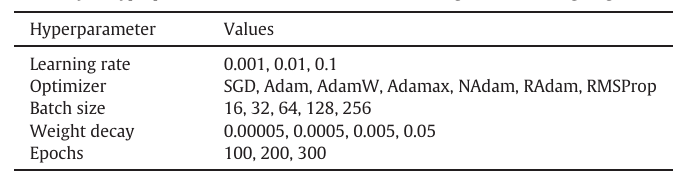

> **1. Learning rate analysis**

>**Hyperparameter : Learning rate**

>**Values : 0.01, 0.001, 0.0001**


In [2]:
!pip install ultralytics -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 20.4 MB/s eta 0:00:00a 0:00:01


In [3]:
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [4]:

!pip uninstall -y ray -q

# Install ultralytics
!pip install ultralytics -q

In [6]:
import os

os.environ["WANDB_DISABLED"] = "true"
os.environ["ULTRALYTICS_DISABLE_RAY"] = "1"

In [7]:
from ultralytics import YOLO
import pandas as pd
import time
import os

# =========================
# CONFIG
# =========================
DATA_PATH = "/kaggle/input/datasets/elieser1945/datasetgray/data.yaml"
learning_rates = [0.01, 0.001, 0.0001]

results_list = []

# =========================
# LOOP TRAINING
# =========================
for lr in learning_rates:
    print(f"\n🚀 Training dengan LR = {lr}")

    model = YOLO("yolo26s.pt")

    start_time = time.time()

    results = model.train(
        data=DATA_PATH,
        epochs=100,
        imgsz=640,
        batch=16,
        optimizer="SGD",
        lr0=lr,
        weight_decay=0.0005,
        project="/kaggle/working",
        name=f"lr_{lr}",
        verbose=False,
        seed=42,
        workers=2
    )

    end_time = time.time()
    training_time_hours = (end_time - start_time) / 3600

    # =========================
    # AMBIL METRIK DARI CSV
    # =========================
    csv_path = os.path.join(results.save_dir, "results.csv")
    df_csv = pd.read_csv(csv_path)

    best_row = df_csv.loc[df_csv['metrics/mAP50(B)'].idxmax()]

    precision = best_row['metrics/precision(B)']
    recall = best_row['metrics/recall(B)']
    map50 = best_row['metrics/mAP50(B)']
    map5095 = best_row['metrics/mAP50-95(B)']

    # F1-score
    f1 = 2 * (precision * recall) / (precision + recall + 1e-6)

    # speed (safe)
    speed = results.speed.get('inference', 0)

    # =========================
    # SIMPAN HASIL
    # =========================
    results_list.append({
        "Learning Rate": lr,
        "Class": "All",
        "Precision": round(precision, 3),
        "Recall": round(recall, 3),
        "F1-score": round(f1, 3),
        "mAP@0.50": round(map50, 3),
        "mAP@0.50:0.95": round(map5095, 3),
        "Training Time (hours)": round(training_time_hours, 3),
        "Speed (ms)": round(speed, 3)
    })

# =========================
# TABEL HASIL
# =========================
df = pd.DataFrame(results_list)

print("\n📊 HASIL EKSPERIMEN LEARNING RATE:")
print(df)

df.to_csv("/kaggle/working/hasil_lr.csv", index=False)


🚀 Training dengan LR = 0.01
Ultralytics 8.4.41 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/input/datasets/elieser1945/datasetgray/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=lr_0.01, nbs=64, nms=False, opset=None, optim